# Pretraining notebook

## Section 1: Generate text before training

Load your current model

Enter a few prompts and note the output.

Try these:
 - love is
 - baby
 - tonight

Generate 20 tokens and note the output.

Reflection: Is there any quality or meaning to the output or is it largely random text?  Why?

In [1]:
import torch

# This makes results more reproducible and reduces confusion when comparing outputs.
torch.manual_seed(123)

from weird_ai.config import PROJECT_ROOT, SAMPLE_LYRICS_FILE
from weird_ai.generation import generate_text_simple, text_to_token_ids, token_ids_to_text
from weird_ai.model import WeirdAIModel
from weird_ai.tokenizer import SimpleCharacterTokenizer

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

with open(SAMPLE_LYRICS_FILE, "r", encoding="utf-8") as f:
    text = f.read()

tokenizer = SimpleCharacterTokenizer(text)

MODEL_CONFIG = {
    "vocab_size": len(tokenizer.chars),
    "context_length": 128,
    "emb_dim": 256,
    "num_layers": 4,
    "num_heads": 1,
    "dropout": 0.1,
    "qkv_bias": False,
}

model = WeirdAIModel(**MODEL_CONFIG).to(device)
model.eval()

print("Vocabulary size:", MODEL_CONFIG["vocab_size"])
print("Parameters:", sum(p.numel() for p in model.parameters()))

prompts = ["love is", "baby", "tonight"]


def generate(model, prompt, max_new_tokens=20):
    model.eval()
    input_ids = text_to_token_ids(prompt, tokenizer).to(device)
    output_ids = generate_text_simple(
        model=model,
        input_ids=input_ids,
        max_new_tokens=max_new_tokens,
        context_size=MODEL_CONFIG["context_length"],
    )
    return token_ids_to_text(output_ids.cpu(), tokenizer)


before_training = {}

for prompt in prompts:
    before_training[prompt] = generate(model, prompt)
    print(repr(before_training[prompt]))

mps
Vocabulary size: 681
Parameters: 3274752
'love is:к소Ü으났Ë光在经듯m잠をh위꺼大로습'
'baby죽好놀ク만소Ü으났돈핑\u205f필力万돈ɔ셔서로'
'tonight름데違\nв딜Ëг좋字灑엇音の据倶디\u205f잃å'


## Section 2: Understanding Logits

Using the logits starter code, do the following:
 - Apply softmax
 - Identify the highest probability token

Reflection: Why is softmax necessary before interpreting logits as probabilities?

In [ ]:
logits = torch.tensor([
    [1.5, 2.0, 0.5]
])

probabilities = torch.softmax(logits, dim=-1)

print(probabilities)
print(probabilities.sum())

predicted_token = torch.argmax(probabilities)

print(predicted_token)

tensor([[0.3315, 0.5465, 0.1220]])
tensor(1.0000)
tensor(1)


## Section 3: Cross Entropy Loss

### Textbook 
The textbook discussion begins on page 136

### Manually calculate
 - Probabilities
 - Log probabilities
 - Average negative log probabilities

### Compare with torch
Compare your manual results to the torch cross entropy results

```python
     torch.nn.functional.cross_entropy(...)
'''


In [15]:
import torch

# Manually calculate values

probs = torch.tensor([
    0.7,
    0.2,
    0.1
])

target_index = 0

In [4]:
target_probability = probs[target_index]

print(target_probability)

tensor(0.7000)


In [5]:
log_probability = torch.log(target_probability)

print(log_probability)

tensor(-0.3567)


In [6]:
loss = -log_probability

print(loss)

tensor(0.3567)


In [7]:
# Compare with torch calculations
manual_loss = -torch.log(probs[target_index])

torch_loss = torch.nn.functional.cross_entropy(
    torch.log(probs).unsqueeze(0),
    torch.tensor([target_index])
)

print("Manual loss:", manual_loss)
print("Torch loss: ", torch_loss)

Manual loss: tensor(0.3567)
Torch loss:  tensor(0.3567)


## Section 4: Perplexity

Compute the perplexity

```python
perplexity = torch.exp(loss)
```

**Note:** A perplexity of 10 means the model is roughly as uncertain as choosing among 10 equally likely next tokens.

In [8]:
loss = torch.tensor(2.5)

perplexity = torch.exp(loss)

print(perplexity)

tensor(12.1825)


## Section 5: Understanding the Training Loop

The training loop performs:

1. Iterate through epochs
2. Iterate through batches
3. Zero gradients
4. Calculate loss
5. Backpropagation
6. Optimizer step
7. Evaluate model
8. Generate sample text

Draw or explain this process in your own words.

# Training vs. Validation

You will:
 - Split lyrics into train/validation
 - Create loaders
 - Compute initial loss

Keep note of your: 
 - Training Loss: 
 - Validation Loss: 

In [9]:
from weird_ai.dataset import LyricsDataset

train_ratio = 0.9

split_index = int(train_ratio * len(text))

train_text = text[:split_index]
val_text = text[split_index:]

print("Training characters:", len(train_text))
print("Validation characters:", len(val_text))

Training characters: 12156964
Validation characters: 1350774


In [10]:
from torch.utils.data import DataLoader, Subset

batch_size = 64
context_length = MODEL_CONFIG["context_length"]


def make_dataset(split_text):
    dataset = LyricsDataset(tokenizer.encode(split_text), context_length)
    return Subset(dataset, range(0, len(dataset), context_length))


train_dataset = make_dataset(train_text)
val_dataset = make_dataset(val_text)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print(train_loader)
print(val_loader)

Training batches: 1484
Validation batches: 165


In [13]:
from weird_ai.losses import calc_loss_loader, calculate_perplexity

eval_iter = 20

model.eval()

with torch.no_grad():
    initial_train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    initial_val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

initial_loss = initial_train_loss

print(f"Training loss:   {initial_train_loss:.4f}  (perplexity {calculate_perplexity(initial_train_loss):.2f})")
print(f"Validation loss: {initial_val_loss:.4f}  (perplexity {calculate_perplexity(initial_val_loss):.2f})")

Training loss:   6.7630  (perplexity 865.24)
Validation loss: 6.7669  (perplexity 868.61)


## Section 6: Training

Train for one Epoch
```python
train_model(...)
```

Then record the loss before and after training.  

In [16]:
import time

from weird_ai.trainer import train_model_simple

num_epochs = 3

optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)

start_time = time.time()

train_losses, val_losses, track_tokens_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=200,
    eval_iter=eval_iter,
    start_context="love is",
    tokenizer=tokenizer,
    context_size=context_length,
)

print(f"Training time: {(time.time() - start_time) / 60:.2f} minutes")

model.eval()

with torch.no_grad():
    final_train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    final_val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

final_loss = final_train_loss


Ep 1 (Step 000000): Train loss 1.968, Val loss 1.968
Ep 1 (Step 000200): Train loss 1.818, Val loss 1.822
Ep 1 (Step 000400): Train loss 1.741, Val loss 1.735
Ep 1 (Step 000600): Train loss 1.666, Val loss 1.677
Ep 1 (Step 000800): Train loss 1.621, Val loss 1.624
Ep 1 (Step 001000): Train loss 1.574, Val loss 1.577
Ep 1 (Step 001200): Train loss 1.513, Val loss 1.533
Ep 1 (Step 001400): Train loss 1.499, Val loss 1.500
love is the start I got the start to start to start to st
Ep 2 (Step 001600): Train loss 1.463, Val loss 1.475
Ep 2 (Step 001800): Train loss 1.437, Val loss 1.451
Ep 2 (Step 002000): Train loss 1.415, Val loss 1.438
Ep 2 (Step 002200): Train loss 1.396, Val loss 1.421
Ep 2 (Step 002400): Train loss 1.386, Val loss 1.410
Ep 2 (Step 002600): Train loss 1.382, Val loss 1.398
Ep 2 (Step 002800): Train loss 1.352, Val loss 1.388
love is a bitches and the bitches and the bitches and the
Ep 3 (Step 003000): Train loss 1.338, Val loss 1.377
Ep 3 (Step 003200): Train loss 1.334

In [17]:
print(f"Initial loss: {initial_loss}")
print(f"Final loss: {final_loss}")
print()
print(f"Validation loss before: {initial_val_loss:.4f}  (perplexity {calculate_perplexity(initial_val_loss):.2f})")
print(f"Validation loss after:  {final_val_loss:.4f}  (perplexity {calculate_perplexity(final_val_loss):.2f})")

Initial loss: 6.763003468513489
Final loss: 1.2916194021701812

Validation loss before: 6.7669  (perplexity 868.61)
Validation loss after:  1.3283  (perplexity 3.77)


## Evaluation

Did the loss decrease?

Why is decreasing loss important?

## Before and After Comparison

Prompt:

love is

Before Training:
__________________

After Training:
__________________

Reflection:

How did the output change?

What evidence do you see that the model learned something from the training data?

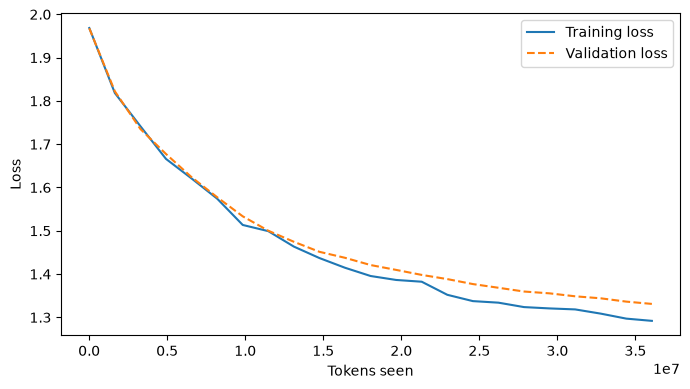

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(track_tokens_seen, train_losses, label="Training loss")
ax.plot(track_tokens_seen, val_losses, linestyle="--", label="Validation loss")
ax.set_xlabel("Tokens seen")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
after_training = {}

for prompt in prompts:
    after_training[prompt] = generate(model, prompt, max_new_tokens=100)
    print("Prompt:", prompt)
    print("Before training:", repr(before_training[prompt]))
    print("After training: ", repr(after_training[prompt]))
    print()

Prompt: love is
Before training: 'love is:к소Ü으났Ë光在经듯m잠をh위꺼大로습'
After training:  "love is the streets\nI don't wanna be a streets\nI don't wanna be a streets\nI don't wanna be a streets\nI don'"

Prompt: baby
Before training: 'baby죽好놀ク만소Ü으났돈핑\u205f필力万돈ɔ셔서로'
After training:  "baby\nI don't wanna be a bitch of the baby\nI don't wanna be a bitch of the baby\nI don't wanna be a bitch "

Prompt: tonight
Before training: 'tonight름데違\nв딜Ëг좋字灑엇音の据倶디\u205f잃å'
After training:  'tonight\nI want you to say you to say you to say you to say you to say you to say you to say you to say you '



## Save the Pretrained Checkpoint

In [21]:
from weird_ai.trainer import save_checkpoint

checkpoint_dir = PROJECT_ROOT / "models" / "lesson-05-pretrained"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / "checkpoint.pt"

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=num_epochs,
    train_losses=train_losses,
    val_losses=val_losses,
    track_tokens_seen=track_tokens_seen,
    checkpoint_path=checkpoint_path,
)

print("Saved:", checkpoint_path)
print(f"Size: {checkpoint_path.stat().st_size / 1e6:.1f} MB")

Saved: /Users/ashton/Weird AI/WeirdAIStarter/models/lesson-05-pretrained/checkpoint.pt
Size: 39.6 MB


## Verify the Checkpoint

In [22]:
from weird_ai.trainer import load_checkpoint

restored_model = WeirdAIModel(**MODEL_CONFIG).to(device)
restored_optimizer = torch.optim.AdamW(restored_model.parameters(), lr=4e-4, weight_decay=0.1)

metadata = load_checkpoint(
    model=restored_model,
    optimizer=restored_optimizer,
    checkpoint_path=checkpoint_path,
    device=device,
)

restored_model.eval()

print("Completed epochs:     ", metadata["epoch"])
print("Evaluation points:    ", len(metadata["train_losses"]))
print("Final training loss:  ", round(metadata["train_losses"][-1], 4))
print("Final validation loss:", round(metadata["val_losses"][-1], 4))
print("Tokens seen:          ", metadata["track_tokens_seen"][-1])
print("Optimizer steps:      ", int(restored_optimizer.state_dict()["state"][0]["step"]))

Completed epochs:      3
Evaluation points:     23
Final training loss:   1.2919
Final validation loss: 1.331
Tokens seen:           36052992
Optimizer steps:       4452


In [23]:
with torch.no_grad():
    restored_val_loss = calc_loss_loader(val_loader, restored_model, device, num_batches=eval_iter)

print(f"Trained model validation loss:  {final_val_loss:.4f}")
print(f"Restored model validation loss: {restored_val_loss:.4f}")
print()

for prompt in prompts:
    restored_text = generate(restored_model, prompt, max_new_tokens=100)
    print("Prompt:", prompt)
    print("Trained model: ", repr(after_training[prompt]))
    print("Restored model:", repr(restored_text))
    print("Match:", restored_text == after_training[prompt])
    print()

Trained model validation loss:  1.3283
Restored model validation loss: 1.3283

Prompt: love is


NameError: name 'after_training' is not defined